# 03 — Regressão, anomalias e consolidação final

> **Etapa 3 · ML** · Gera `data/processed/modelagem_resultados.parquet` (insumo do script 08 de publicação).
> Escopo: discussão §4.4 e §4.6 e plano §4.5–4.6.

Três entregas:
1. **Explicar o IPB** — regressão com alvo = IPB. O acerto sai alto *por construção* (as features já estão na fórmula — o modelo só decora a receita; circularidade **declarada**). O produto é a **ordem de importância**: “o que pesa no índice?” respondido com número.
2. **Potencial latente** — “precificar imóvel”: o modelo aprende (só nos municípios **com** agência) como perfil socioeconômico + digital vira depósito per capita — **sem** usar variáveis de presença como preditora — e estima quanto cada cidade **sem** agência depositaria se tivesse banco. Cruzamento por Spearman com o IPB: se bater alto, o índice é validado por via independente.
3. **Anomalias** — os ~30 municípios mais atípicos do Brasil bancário para leitura humana.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Sobe ate a raiz do projeto (pasta src/) para importar os modulos e
# achar data/, independente de onde o kernel iniciou.
caminho = Path.cwd()
while not (caminho / "src").is_dir() and caminho != caminho.parent:
    caminho = caminho.parent
sys.path.insert(0, str(caminho))

DATA = caminho / "data" / "processed"
FIGS = DATA / "figures"
FIGS.mkdir(exist_ok=True)
SEED = 42

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

from src.analytics.modelagem import (
    ALVOS,
    COLUNAS_IDENTIDADE,
    FEATURES_MODELO,
    FEATURES_SEM_PRESENCA,
    N_MUNICIPIOS_ESPERADO,
    montar_dataset_modelagem,
    padronizar,
    dividir_treino_teste,
)
from src.analytics import clustering as clu


Carrega o dataset e define o mesmo `K_ESCOLHIDO` dos notebooks anteriores (mesma seed, mesmos labels).

In [2]:
df = pd.read_parquet(DATA / "modelagem.parquet")

K_ESCOLHIDO = 6  # MESMO valor do notebook 01

## 1. Explicar o IPB (sanity check circular, declarado)

Métricas em linguagem simples: **MAE** = quanto o modelo erra em média (em pontos de IPB); **RMSE** = idem, mas castiga erro grande; **R²** = quanto da variação do IPB o modelo explica (1 = tudo, 0 = chutar a média). Aqui o R² **deve** sair alto — e isso não é mérito, é a circularidade funcionando. O que importa é a importância por permutação do Random Forest: a queda de R² ao embaralhar cada variável.

In [3]:
from src.analytics import regressao as reg

matriz_ipb, importancia_ipb = reg.explicar_ipb(df)
matriz_ipb.round(3)

,modelo,mae,rmse,r2,tempo_seg
0,random_forest,1.918,2.876,0.938,158.503
1,ridge,3.161,5.081,0.808,0.016
2,lasso,3.700,5.785,0.751,0.059


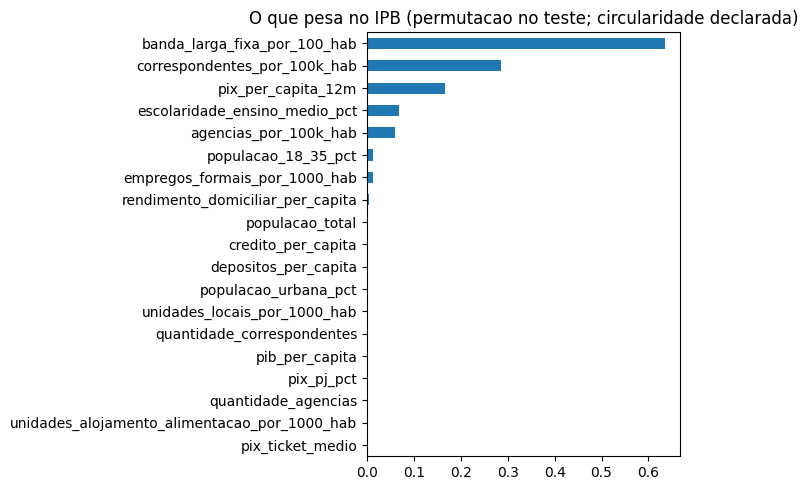

In [4]:
ax = importancia_ipb.sort_values().plot.barh(
    figsize=(7, 5),
    title="O que pesa no IPB (permutacao no teste; circularidade declarada)",
)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(FIGS / "03_importancia_ipb.png", dpi=110)
plt.show()

## 2. Potencial latente

O holdout interno (só entre os **com** agência) calibra a confiança: MAE/RMSE em R$ de depósito per capita e R² na escala original. Depois a estimativa para os **sem** agência. Onde já tem agência fica `NaN` — não se estima o que já se observa.

In [5]:
estimativas, metricas_latente = reg.estimar_potencial_latente(df)
metricas_latente.round(3)

,mae,rmse,r2,n_treino,n_teste
0,0.446,0.618,0.475,2331,583


Spearman(potencial latente, IPB V3) nos 2656 sem agencia: 0.449 (p=6.20e-132)


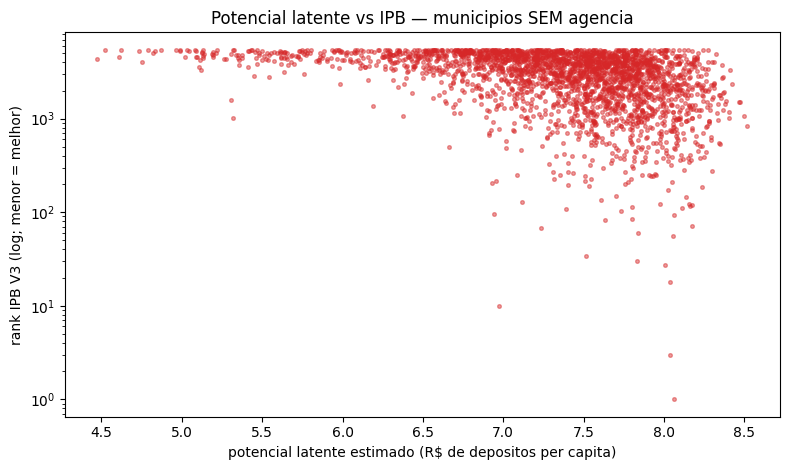

In [6]:
df["potencial_latente_depositos_pc"] = estimativas

from scipy.stats import spearmanr

sem_agencia = df["potencial_latente_depositos_pc"].dropna()
rho, p_valor = spearmanr(sem_agencia, df.loc[sem_agencia.index, "ipb"])
print(f"Spearman(potencial latente, IPB V3) nos {len(sem_agencia)} sem agencia: {rho:.3f} (p={p_valor:.2e})")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(sem_agencia, df.loc[sem_agencia.index, "rank"], s=7, alpha=0.45, color="#d62728")
ax.set_yscale("log")
ax.set_xlabel("potencial latente estimado (R$ de depositos per capita)")
ax.set_ylabel("rank IPB V3 (log; menor = melhor)")
ax.set_title("Potencial latente vs IPB — municipios SEM agencia")
fig.tight_layout()
fig.savefig(FIGS / "03_potencial_latente_vs_ipb.png", dpi=110)
plt.show()

Leitura: se Spearman for alto e positivo, cidades que o IPB ranqueia bem também têm alto potencial latente — o índice captura essa dimensão. Divergências (pontos altos à direita com rank ruim) são candidatos a discussão: o IPB sub-premia algum perfil? Isso vai para o relatório.

## 3. Anomalias — os municípios mais atípicos

In [7]:
from src.analytics import anomalias as anom

anomalias_df = anom.detectar_anomalias(df, FEATURES_MODELO, n_top=30)
df = df.join(anomalias_df)

top30 = df[df["flag_anomalia"]].sort_values("score_anomalia", ascending=False)
top30[["id_municipio", "nome_municipio", "sigla_uf", "estrato_populacional",
       "ipb", "rank", "score_anomalia"]].head(15)

,id_municipio,nome_municipio,sigla_uf,estrato_populacional,ipb,rank,score_anomalia
2924,2605459,Fernando de Noronha,PE,pequena,37.718495,2578,0.145970
3195,4106902,Curitiba,PR,grande,61.853458,47,0.139789
4791,3505708,Barueri,SP,media,65.905642,17,0.138127
4821,3548807,São Caetano do Sul,SP,media,58.900807,112,0.137254
4825,3550308,São Paulo,SP,grande,66.515364,15,0.133807
4421,4205407,Florianópolis,SC,grande,68.850909,9,0.133348
810,3205309,Vitória,ES,media,62.152999,44,0.130189
5162,3500600,Águas de São Pedro,SP,pequena,37.657741,2596,0.125909
4416,4202008,Balneário Camboriú,SC,media,70.998705,4,0.121919
3929,4314902,Porto Alegre,RS,grande,63.548122,29,0.120054


In [8]:
comparacao = pd.DataFrame({
    "top30_anomalias": df[df["flag_anomalia"]][FEATURES_MODELO].mean(),
    "media_geral": df[FEATURES_MODELO].mean(),
})
comparacao["razao"] = (comparacao["top30_anomalias"] / comparacao["media_geral"]).round(2)
comparacao.sort_values("razao", ascending=False).round(2)

,top30_anomalias,media_geral,razao
quantidade_agencias,3.30,0.66,5.00
unidades_alojamento_alimentacao_por_1000_hab,1.64,0.78,2.10
credito_per_capita,9.10,4.61,1.97
quantidade_correspondentes,5.56,2.84,1.96
banda_larga_fixa_por_100_hab,36.07,19.10,1.89
depositos_per_capita,7.77,4.16,1.87
pix_pj_pct,0.59,0.33,1.76
agencias_por_100k_hab,2.15,1.22,1.76
escolaridade_ensino_medio_pct,61.38,39.51,1.55
populacao_total,12.51,9.44,1.33


Leitura: razão > 1 = o grupo anômalo tem a variável **acima** da média nacional (ex.: renda altíssima sem banco); razão < 1 = **abaixo**. Combinações estranhas (alta renda + zero presença) são os casos que valem leitura de negócio no relatório.

## 4. Consolidação final — `modelagem_resultados.parquet`

Junta tudo que o script 08 (`scripts/08_publica_clusters_bigquery.py`) sobe como `analytics_ipb_clusters`:

- identidade + clusters (K-Means/GMM) + prob. GMM + **arquetipo** (nome sugerido, pendente de validação);
- probabilidade do RF **refitado em 100%** dos dados, alvo tem-agência (avaliação honesta foi no holdout do notebook 02 — o refit em tudo é o produto final, padrão de projeto);
- potencial latente + anomalia;
- `ipb`/`rank` como **referência de cruzamento** (nunca feature).

> O alvo tem-correspondente saiu do consolidado: a flag é degenerada (100% dos municípios têm correspondente — notebook 02, seção 2). Probabilidade constante 1.0 não carrega informação.

In [9]:
from sklearn.ensemble import RandomForestClassifier

_, labels_km, _ = clu.ajustar_kmeans(df, FEATURES_MODELO, k=K_ESCOLHIDO)
_, labels_gmm, probs_gmm, _ = clu.ajustar_gmm(df, FEATURES_MODELO, k=K_ESCOLHIDO)
perfis = clu.perfis_clusters(df, FEATURES_MODELO, labels_km)
nomes = clu.sugerir_nomes_perfis(perfis)

# RF refitado em 100% com as 13 exogenas (sem vazamento de presenca —
# avaliacao honesta no holdout do notebook 02; refit e o produto final).
rf_agencia = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1
)
rf_agencia.fit(df[FEATURES_SEM_PRESENCA], df["flag_tem_agencia"])
prob_agencia = rf_agencia.predict_proba(df[FEATURES_SEM_PRESENCA])[:, 1]

consolidado = pd.DataFrame({
    "id_municipio": df["id_municipio"].astype(str).str.zfill(7),
    "nome_municipio": df["nome_municipio"],
    "sigla_uf": df["sigla_uf"],
    "nome_regiao": df["nome_regiao"],
    "estrato_populacional": df["estrato_populacional"],
    "cluster_kmeans": labels_km.astype(int).to_numpy(),
    "cluster_gmm": labels_gmm.astype(int).to_numpy(),
    "prob_cluster_gmm": probs_gmm.max(axis=1).round(4),
    "arquetipo": labels_km.map(nomes),
    "prob_tem_agencia_rf": prob_agencia.round(4),
    "pred_tem_agencia_rf": (prob_agencia >= 0.5).astype(int),
    "potencial_latente_depositos_pc": df["potencial_latente_depositos_pc"],
    "score_anomalia": df["score_anomalia"].round(4),
    "flag_anomalia_top30": df["flag_anomalia"].astype(bool),
    "ipb": df["ipb"],
    "rank": df["rank"],
})
consolidado.to_parquet(DATA / "modelagem_resultados.parquet", index=False)

print(f"consolidado: {consolidado.shape[0]} linhas x {consolidado.shape[1]} colunas")
consolidado.head()

consolidado: 5570 linhas x 16 colunas


,id_municipio,nome_municipio,sigla_uf,nome_regiao,estrato_populacional,cluster_kmeans,cluster_gmm,prob_cluster_gmm,arquetipo,prob_tem_agencia_rf,pred_tem_agencia_rf,potencial_latente_depositos_pc,score_anomalia,flag_anomalia_top30,ipb,rank
0,1200401,Rio Branco,AC,Norte,media,0,4,1.0000,Turismo,1.0000,1,NaN,0.0173,False,59.886902,86
1,1200179,Capixaba,AC,Norte,pequena,1,1,1.0000,Sem rede bancaria,0.0667,0,7.129226,-0.0718,False,30.070560,4135
2,1200328,Jordão,AC,Norte,pequena,1,5,0.9951,Sem rede bancaria,0.0400,0,5.461808,-0.0218,False,27.902725,4467
3,1200336,Mâncio Lima,AC,Norte,pequena,1,2,1.0000,Sem rede bancaria,0.2267,0,6.590127,-0.0400,False,33.903223,3354
4,1200351,Marechal Thaumaturgo,AC,Norte,pequena,1,2,0.5862,Sem rede bancaria,0.1300,0,6.049884,0.0442,False,23.513906,5005


## 5. Decisões registradas deste notebook

1. Métricas do holdout interno do potencial latente (confiança nas estimativas).
2. Spearman potencial latente × IPB — validação cruzada do índice.
3. Top 30 anômalos + perfil comparado à média nacional.
4. `modelagem_resultados.parquet` pronto para o script 08 de publicação no BigQuery.